**Objective II - Selecting best model architecture**

In [93]:
import json
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [94]:
with open("../src/experiments/results/objective_II/models_performance.json", "r") as file:
    data = json.load(file)

models = []
language_scores = defaultdict(list)

for model, results in data.items():
    total_model_score = 0
    for language, scores in results.items():
        language_scores[language].append(round(scores["test_f1"], 5))
        total_model_score += round(scores["test_f1"], 5)
    print("Model: {}".format(model))
    print("Avg. Score: {}".format(total_model_score / 6))
    print()
    models.append(model)

Model: BERT
Avg. Score: 0.8340650000000002

Model: BERT-CRF
Avg. Score: 0.8646416666666666

Model: BERT-Bilstm
Avg. Score: 0.8304816666666667

Model: BERT-Bilstm-CRF
Avg. Score: 0.8700649999999999



In [95]:
# How much better is BERT-BiLSTM-CRF?
print(f"BERT-BiLSTM-CRF is {(0.867165 - 0.8412716666666666) / 0.8412716666666666 * 100} % better than BERT")
print(f"BERT-BiLSTM-CRF is {(0.867165 - 0.8558850000000001) / 0.8558850000000001 * 100} % better than BERT-CRF")
print(f"BERT-BiLSTM-CRF is {(0.867165 - 0.8256216666666667) / 0.8256216666666667 * 100} % better than BERT-BILSTM")

BERT-BiLSTM-CRF is 3.077880114033714 % better than BERT
BERT-BiLSTM-CRF is 1.3179340682451315 % better than BERT-CRF
BERT-BiLSTM-CRF is 5.03176394353345 % better than BERT-BILSTM


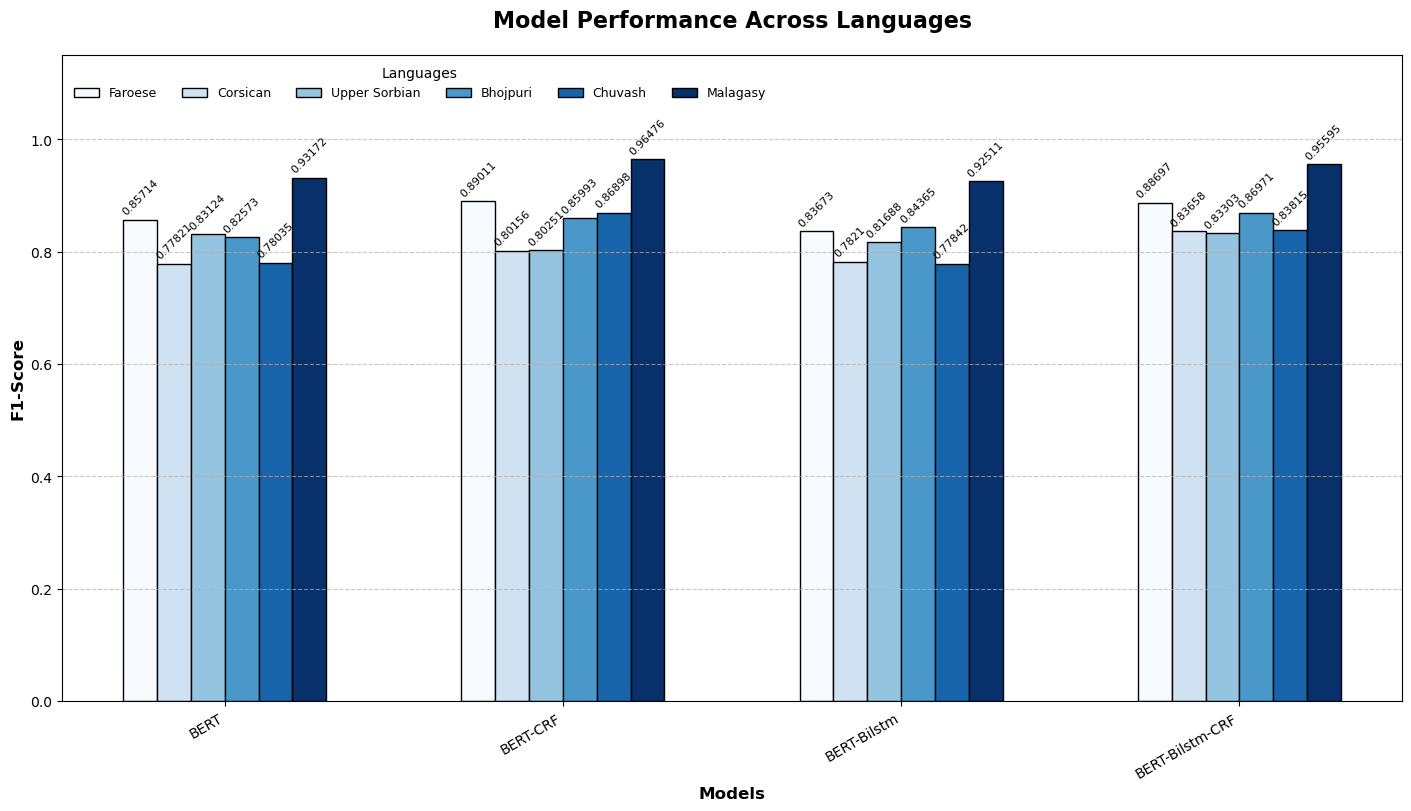

In [96]:
x = np.arange(len(models))
fig, ax = plt.subplots(layout="constrained", figsize=(14, 8))

width = 0.1
multiplier = -2

colors = plt.get_cmap("Blues", len(language_scores))

legend_codes = {'mg': 'Malagasy', 'fo': 'Faroese', 'co': 'Corsican', 'hsb': 'Upper Sorbian', 'bh': 'Bhojpuri', 'cv': 'Chuvash'}

for idx, (language, scores) in enumerate(language_scores.items()):
    offset = width * multiplier
    rects = ax.bar(
        x + offset,
        scores,
        width,
        label=legend_codes[language],
        color=colors(idx),
        edgecolor='black'
    )
    ax.bar_label(rects, padding=2, fontsize=8, rotation=45)
    multiplier += 1

ax.set_ylabel("F1-Score", fontsize=12, weight="bold")
ax.set_xlabel("Models", fontsize=12, weight="bold")
ax.set_title("Model Performance Across Languages", fontsize=16, weight="bold", pad=20)
ax.set_xticks(x + width / 2, labels=models, fontsize=10, rotation=30, ha="right")
ax.set_ylim(0, 1.15)

ax.grid(axis="y", linestyle="--", alpha=0.7)

ax.legend(
    title="Languages",
    title_fontsize=10,
    fontsize=9,
    loc="upper left",
    ncols=6,
    frameon=False
)

plt.show()

**Objective III - training baseline model**

In [97]:
with open("../src/experiments/results/objective_III/baseline_model_performance.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
baseline_language_scores = {}

total_model_score = 0
for language, scores in data.items():
    baseline_language_scores[language] = round(scores["test_f1"], 5)
    total_model_score += round(scores["test_f1"], 5)

print("\nModel: {}\n".format(model))
pprint(baseline_language_scores)
print("\nAvg. Score: {}".format(total_model_score / 6))
print()


Model: BERT-CRF

{'bh': 0.86482,
 'co': 0.81712,
 'cv': 0.81696,
 'fo': 0.88697,
 'hsb': 0.83842,
 'mg': 0.95595}

Avg. Score: 0.8633733333333334



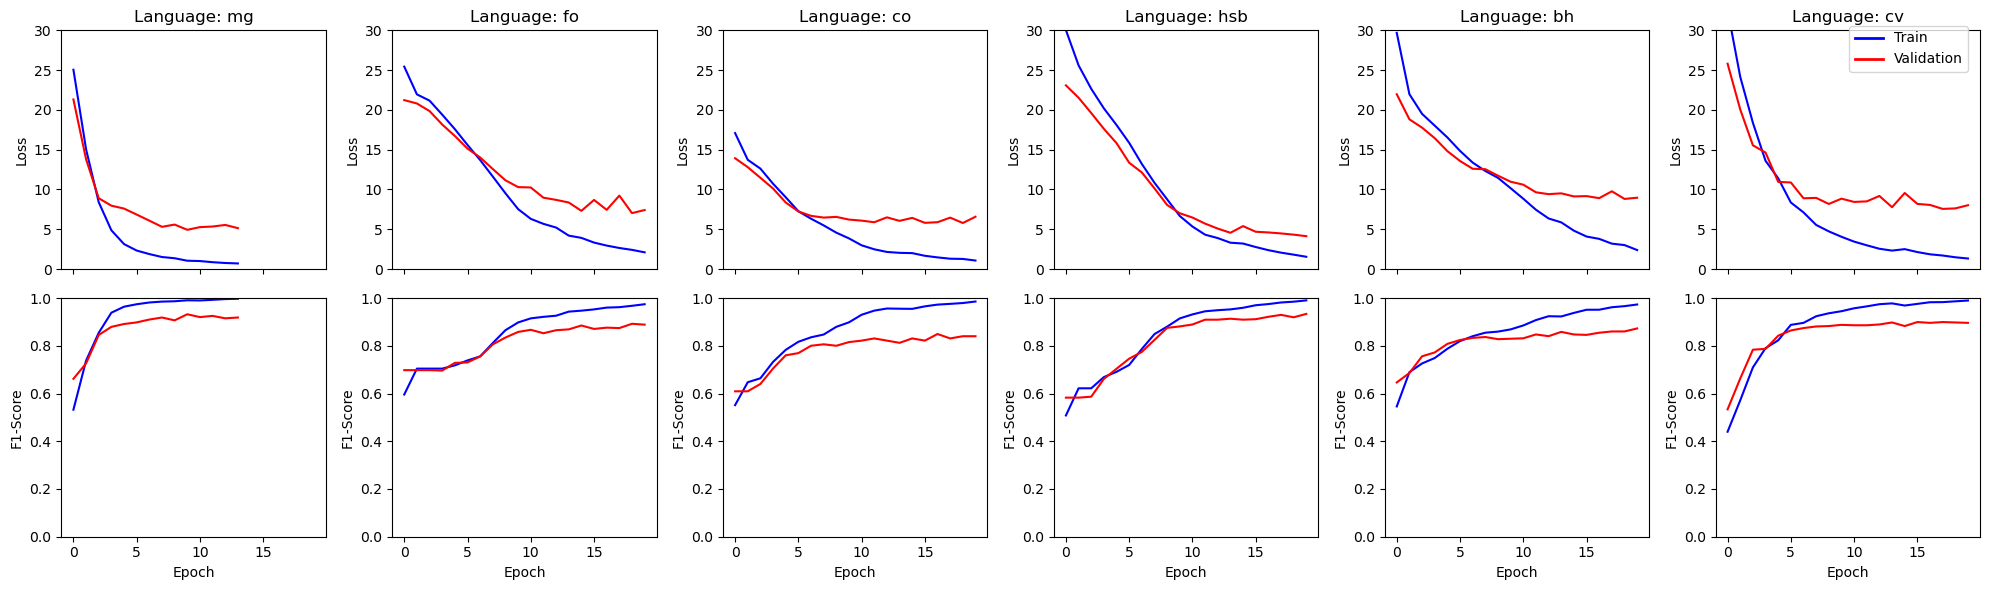

In [98]:
with open("../src/experiments/results/objective_III/baseline_model_logging.json", "r") as file:
    logging = json.load(file)

fig, axes = plt.subplots(2, 6, figsize=(20, 6), sharex=True)

for idx, (language_code, metrics) in enumerate(logging.items()):
    train_losses = metrics["train_losses"]
    val_losses = metrics["val_losses"]
    train_f1s = metrics["train_f1s"]
    val_f1s = metrics["val_f1s"]

    axes[0][idx].plot(train_losses, color='blue', label='Train Loss')
    axes[0][idx].plot(val_losses, color='red', label='Validation Loss')
    axes[1][idx].plot(train_f1s, color='blue', label='Train F1-Score')
    axes[1][idx].plot(val_f1s, color='red', label='Validation F1-Score')

    axes[0][idx].set_title(f"Language: {language_code}", fontsize=12)
    axes[0][idx].set_ylabel("Loss", fontsize=10)
    axes[0][idx].set_ylim([0, 30])

    axes[1][idx].set_ylabel("F1-Score", fontsize=10)
    axes[1][idx].set_xlabel("Epoch", fontsize=10)
    axes[1][idx].set_ylim([0, 1])
    
# Add legend
lines = [plt.Line2D([0], [0], color='blue', lw=2),
         plt.Line2D([0], [0], color='red', lw=2)]
labels = ['Train', 'Validation']
fig.legend(lines, labels, loc='upper right', fontsize=10, bbox_to_anchor=(0.99, 0.96))

plt.tight_layout()
plt.show()

**Objective IV - Cross-lingual transfer learning**

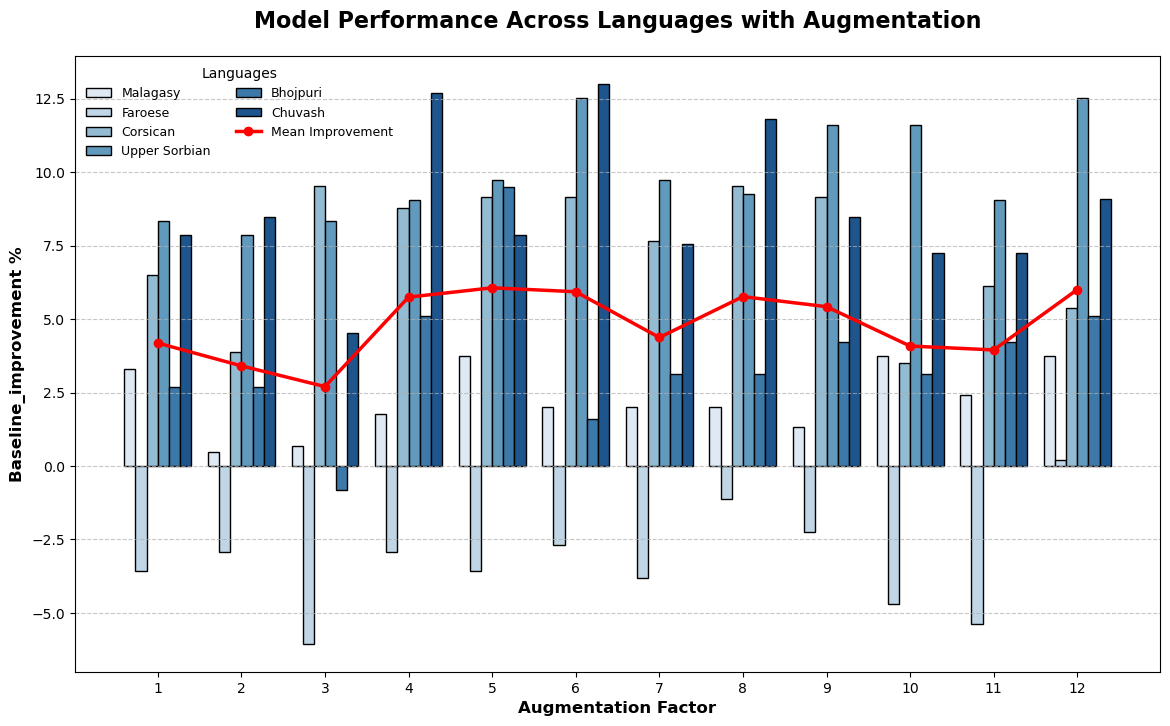

In [99]:
import seaborn as sns
import pandas as pd

import os
import re
from collections import defaultdict

lang_codes = {'mg_id': 'mg','fo_is': 'fo','co_it': 'co','hsb_pl': 'hsb','bh_hi': 'bh','cv_tt': 'cv'}
legend_codes = {'mg_id': 'Malagasy', 'fo_is': 'Faroese','co_it': 'Corsican','hsb_pl': 'Upper Sorbian','bh_hi': 'Bhojpuri','cv_tt': 'Chuvash'}
augmentation_data = defaultdict(dict)
augementation_factors = []

for filename in os.listdir("../src/experiments/results/objective_IV"):
    with open(f"../src/experiments/results/objective_IV/{filename}") as file:
        data = json.load(file)

        filename = filename.replace(".json", "")

        augementation_factor = int(re.search(r'\d+$', filename).group())
        augementation_factors.append(augementation_factor)

        for language, scores in data.items():
            augmentation_data[augementation_factor][language] = round(scores["test_f1"], 5)

# Prepare the data for seaborn
plot_data = []
for aug_factor, scores in augmentation_data.items():
    for language, score in scores.items():
        baseline_score = baseline_language_scores[lang_codes[language]]
        improvement = ((score - baseline_score) / baseline_score) * 100
        plot_data.append({'Augmentation Factor': aug_factor, 'Language': language, 'F1-Score': score, 'Baseline_improvement': improvement})

df_plot = pd.DataFrame(plot_data)
df_plot["Language"] = df_plot["Language"].map(legend_codes)

# Create the seaborn plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Augmentation Factor', y='Baseline_improvement', hue='Language', data=df_plot, palette='Blues', edgecolor="black")

# Add a red line for the mean baseline improvement
mean_improvement = df_plot.groupby("Augmentation Factor")["Baseline_improvement"].mean().reset_index()
mean_improvement["Augmentation Factor"] -= 1
plt.plot(mean_improvement["Augmentation Factor"], mean_improvement["Baseline_improvement"], color='red', marker='o', linewidth=2.5, label='Mean Improvement')

plt.title('Model Performance Across Languages with Augmentation', fontsize=16, weight='bold', pad=20)
plt.xlabel('Augmentation Factor', fontsize=12, weight='bold')
plt.ylabel('Baseline_improvement %', fontsize=12, weight='bold')
plt.legend(title='Languages', title_fontsize=10, fontsize=9, loc='upper left', ncol=2, frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


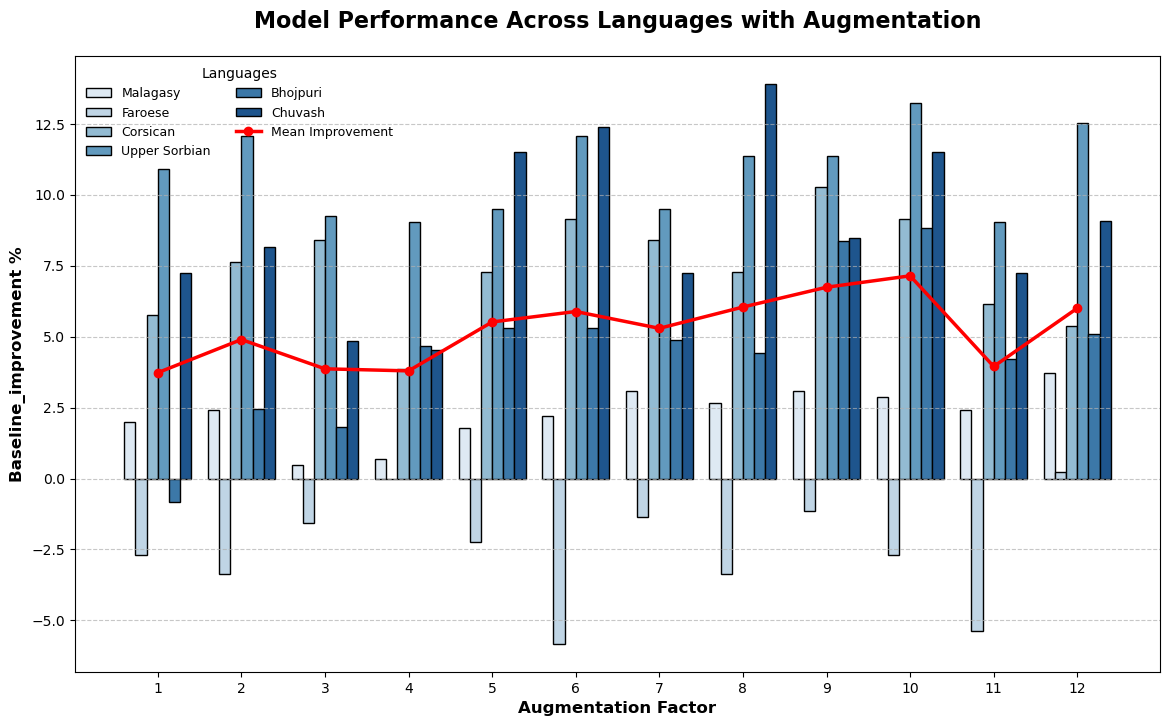

In [100]:
import seaborn as sns
import pandas as pd

import os
import re
from collections import defaultdict

lang_codes = {'mg_id': 'mg','fo_is': 'fo','co_it': 'co','hsb_pl': 'hsb','bh_hi': 'bh','cv_tt': 'cv'}
legend_codes = {'mg_id': 'Malagasy', 'fo_is': 'Faroese','co_it': 'Corsican','hsb_pl': 'Upper Sorbian','bh_hi': 'Bhojpuri','cv_tt': 'Chuvash'}
augmentation_data = defaultdict(dict)
augementation_factors = []

for filename in os.listdir("../src/experiments/results/objective_IV"):
    if filename[:4] == "new_":
        with open(f"../src/experiments/results/objective_IV/{filename}") as file:
            data = json.load(file)

            filename = filename.replace(".json", "")

            augementation_factor = int(re.search(r'\d+$', filename).group())
            augementation_factors.append(augementation_factor)

            for language, scores in data.items():
                augmentation_data[augementation_factor][language] = round(scores["test_f1"], 5)

# Prepare the data for seaborn
plot_data = []
for aug_factor, scores in augmentation_data.items():
    for language, score in scores.items():
        baseline_score = baseline_language_scores[lang_codes[language]]
        improvement = ((score - baseline_score) / baseline_score) * 100
        plot_data.append({'Augmentation Factor': aug_factor, 'Language': language, 'F1-Score': score, 'Baseline_improvement': improvement})

df_plot = pd.DataFrame(plot_data)
df_plot["Language"] = df_plot["Language"].map(legend_codes)

# Create the seaborn plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Augmentation Factor', y='Baseline_improvement', hue='Language', data=df_plot, palette='Blues', edgecolor="black")

# Add a red line for the mean baseline improvement
mean_improvement = df_plot.groupby("Augmentation Factor")["Baseline_improvement"].mean().reset_index()
mean_improvement["Augmentation Factor"] -= 1
plt.plot(mean_improvement["Augmentation Factor"], mean_improvement["Baseline_improvement"], color='red', marker='o', linewidth=2.5, label='Mean Improvement')

plt.title('Model Performance Across Languages with Augmentation', fontsize=16, weight='bold', pad=20)
plt.xlabel('Augmentation Factor', fontsize=12, weight='bold')
plt.ylabel('Baseline_improvement %', fontsize=12, weight='bold')
plt.legend(title='Languages', title_fontsize=10, fontsize=9, loc='upper left', ncol=2, frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [101]:
((0.92327 - 0.81696) / 0.81696) * 100

13.012877007442224

In [102]:
0.81696
Score:  0.92327

In [103]:
with open("../src/experiments/results/objective_IV/transfer_learning_performance6.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["test_f1"], 5)
    total_model_score += round(scores["test_f1"], 5)

    print(f"Lang: {language}, Test-F1: {scores['test_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: mg_id, Test-F1: 0.97500
Lang: fo_is, Test-F1: 0.86310
Lang: co_it, Test-F1: 0.89198
Lang: hsb_pl, Test-F1: 0.94347
Lang: bh_hi, Test-F1: 0.87856
Lang: cv_tt, Test-F1: 0.92327

Model: BERT-CRF
Avg. Score: 0.9125633333333333



In [104]:
baseline_language_scores

{'mg': 0.95595,
 'fo': 0.88697,
 'co': 0.81712,
 'hsb': 0.83842,
 'bh': 0.86482,
 'cv': 0.81696}

In [105]:
((0.92327 - 0.81696) / 0.81696) * 100

13.012877007442224

In [106]:
mean_improvement

,Augmentation Factor,Baseline_improvement
0,0,3.732746
1,1,4.901847
2,2,3.869261
3,3,3.796929
4,4,5.521009
5,5,5.889829
6,6,5.296892
7,7,6.047409
8,8,6.745790
9,9,7.148129
